# Warfarin: when does individual information improve PK/PD prediction?

Executed review of completed estimation results. Read article.md for methods and limitations. This notebook does not rerun the long R fits; README gives full commands. No raw patient data is distributed.

In [1]:
from pathlib import Path
import json,pandas as pd,numpy as np
from IPython.display import Image,display
R=Path('.')
a=json.loads((R/'results/audit-summary.json').read_text())
assert a['rows']==515 and a['subjects']==32 and a['PD_primary_subjects']==30
assert all(a['original_numeric_match'].values())
print('Acquired original-data match and audit verified')
display(pd.read_csv('results/model-comparison.csv'))

Acquired original-data match and audit verified


,model,AIC,objective,warning
0,direct-refined,-177.721297,-529.242185,True
1,pd-direct,-177.706790,-529.227679,True
2,pd-turnover,-556.826934,-912.347822,True
3,pk-allometry,870.825797,393.518653,True
4,pk-constant,900.678673,423.371529,True
5,pk-refined,900.674547,423.367404,True
6,turn-refined,-556.797268,-912.318156,True
7,weight-refined,870.825409,393.518265,True
8,weight-turn,-553.366358,-908.887247,True


## Subject-separated validation
Only prior PK is used, never future concentrations or postbaseline PCA. Confidence intervals here resample subjects conditional on existing trained folds; model uncertainty remains.

In [2]:
p=pd.read_csv('results/prediction-summary.csv')
assert set(p.subjects)=={29,30}
assert len(p)==6
display(p)
display(pd.read_csv('results/paired-validation.csv'))
s=pd.read_csv('results/run-status.csv')
print('Final runs:',len(s),'finite:',s.finite.sum(),'optimization warnings:',s.warning.sum())
b=pd.read_csv('results/bootstrap-estimates.csv')
assert len(b)==60
print('Bootstrap finite sequences:',len(b),'warning-free:',(~b.warning).sum())

,cutoff,strategy,subjects,RMSE,bootstrap_low,bootstrap_high,direct_RMSE,mean_PK_measurements
0,24,PK-informed,30,0.088735,0.073645,0.103661,0.134645,2.733333
1,24,population,30,0.079949,0.066776,0.092240,0.106139,0.000000
2,24,weight,30,0.081677,0.067399,0.096112,NaN,0.000000
3,48,PK-informed,29,0.107933,0.087745,0.127015,0.148691,4.655172
4,48,population,29,0.097815,0.080642,0.114829,0.117915,0.000000
5,48,weight,29,0.099297,0.079590,0.117824,NaN,0.000000


,cutoff,subjects,mean_MSE_difference,low,high
0,24,30,0.001482,-0.001168,0.004260
1,48,29,0.002082,-0.002596,0.006416


Final runs: 156 finite: 156 optimization warnings: 131
Bootstrap finite sequences: 60 warning-free: 0


## Implementation checks and simulated dose comparison
Numerical agreement does not qualify the model. Dose targets are arbitrary. An oracle is a separate unimplementable bound.

In [3]:
q=pd.read_csv('results/independent-QA.csv')
assert q.max_absolute_error.max()<.001
display(q)
display(pd.read_csv('results/shrinkage.csv'))
x=pd.read_csv('results/scenario-summary.csv')
assert (x.target_fraction.between(0,1)).all()
display(x[x.replicate==0])
display(pd.read_csv('results/scenario-structural-sensitivity.csv'))

,check,max_absolute_error
0,pk-refined,6.750156e-14
1,turn-refined,2.806732e-05
2,direct-refined,1.557814e-06


,model,parameter,variance_shrinkage
0,pk-refined,eta.cl,0.087938
1,pk-refined,eta.v,0.228846
2,pk-refined,eta.ka,0.698884
3,turn-refined,eta.ic,0.065557
4,turn-refined,eta.kout,0.441677


,replicate,strategy,n,nadir_median,nadir_SD,target_fraction,dose_bound_fraction
0,0,PK24,300,0.250767,0.083225,0.460000,0.166667
1,0,PK24+48,300,0.249491,0.081829,0.493333,0.213333
2,0,fixed,300,0.256054,0.085846,0.466667,0.000000
3,0,oracle,300,0.249996,0.040815,0.780000,0.463333
4,0,weight,300,0.252834,0.086582,0.466667,0.250000


,PK_structure,strategy,target_fraction,nadir_SD,dose_bound_fraction
0,constant,PK24,0.460000,0.083225,0.166667
1,constant,PK24+48,0.493333,0.081829,0.213333
2,constant,fixed,0.466667,0.085846,0.000000
3,constant,oracle,0.780000,0.040815,0.463333
4,constant,weight,0.466667,0.086582,0.250000
5,allometry,PK24,0.436667,0.083322,0.233333
6,allometry,PK24+48,0.463333,0.081976,0.256667
7,allometry,fixed,0.416667,0.089272,0.000000
8,allometry,oracle,0.770000,0.041848,0.523333
9,allometry,weight,0.463333,0.083765,0.250000


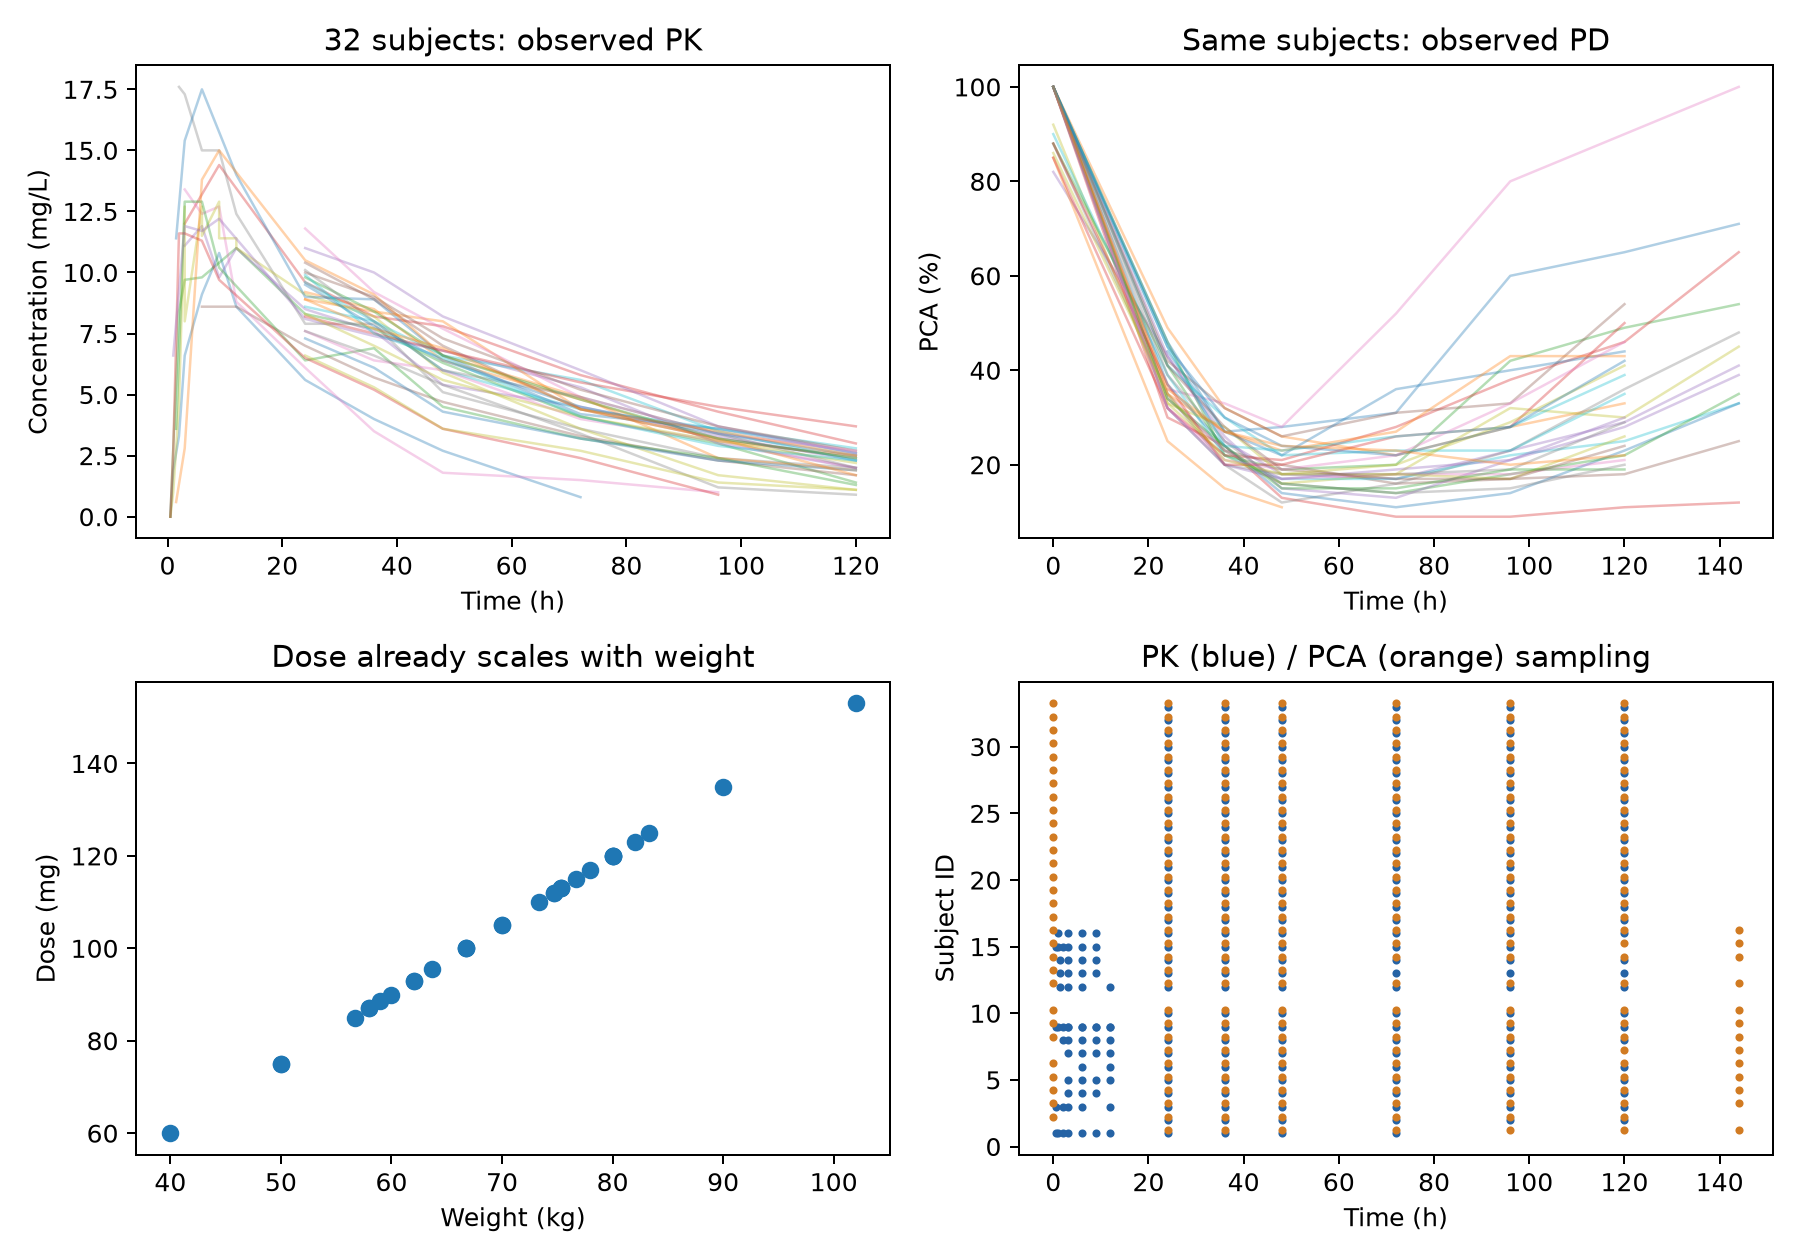

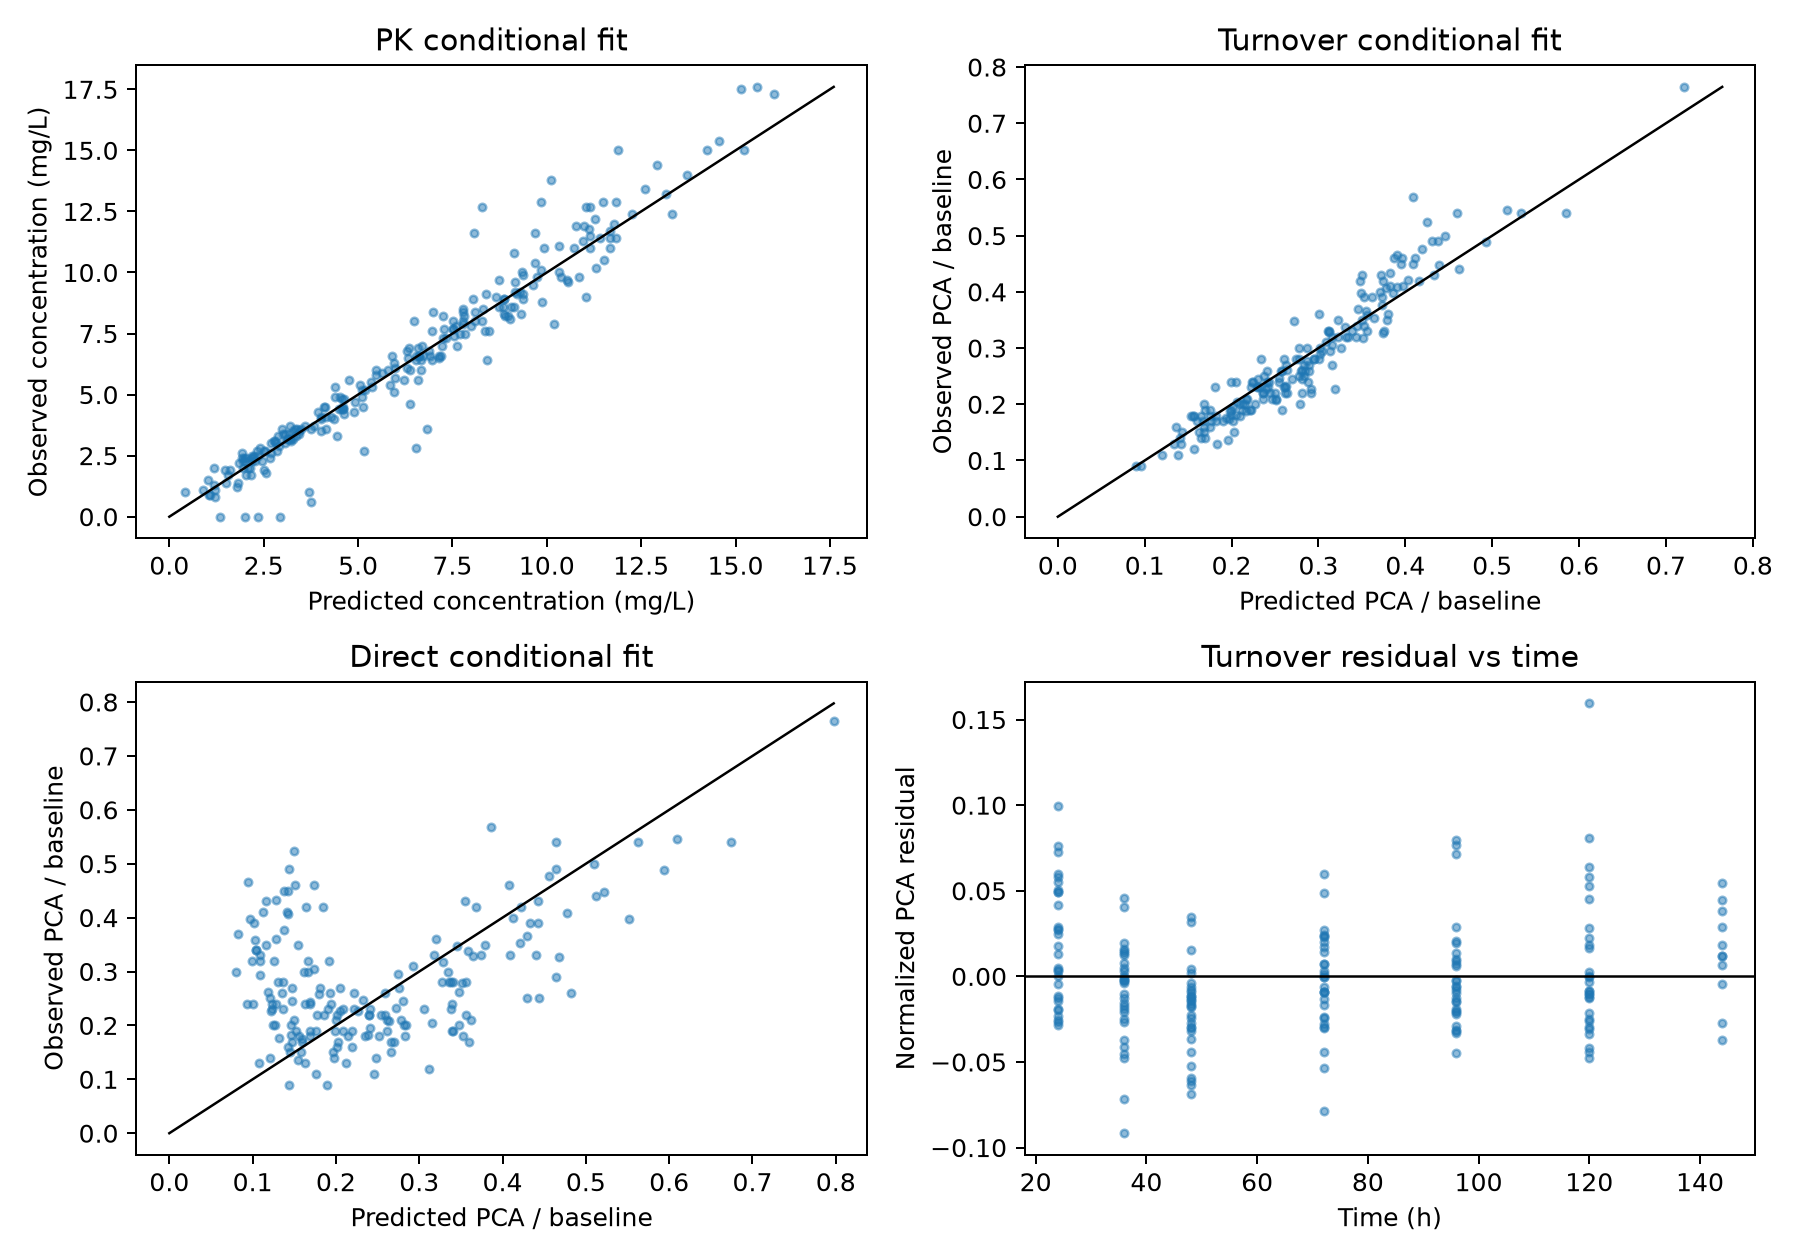

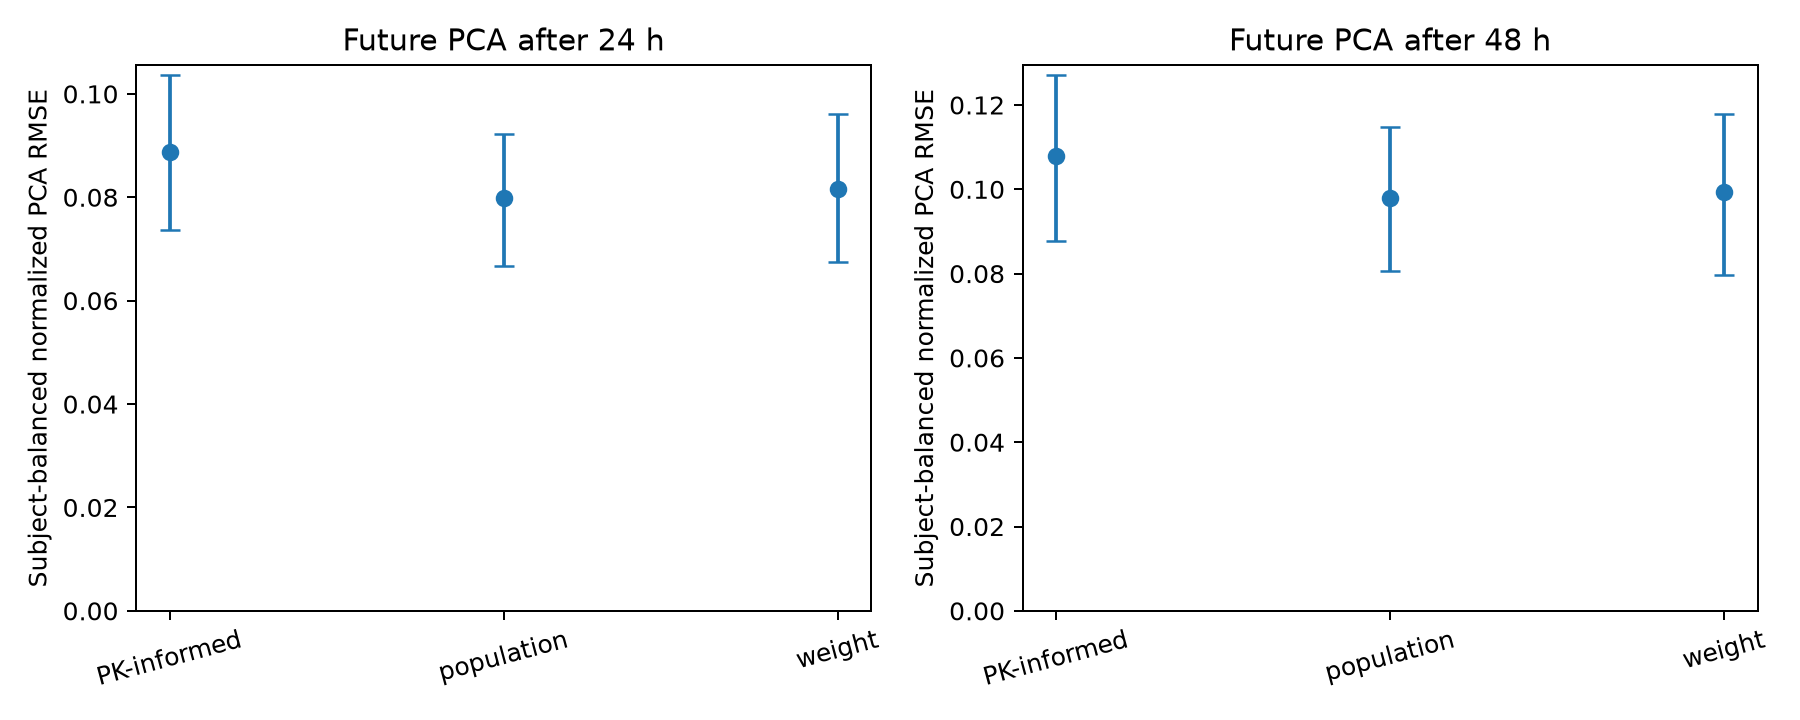

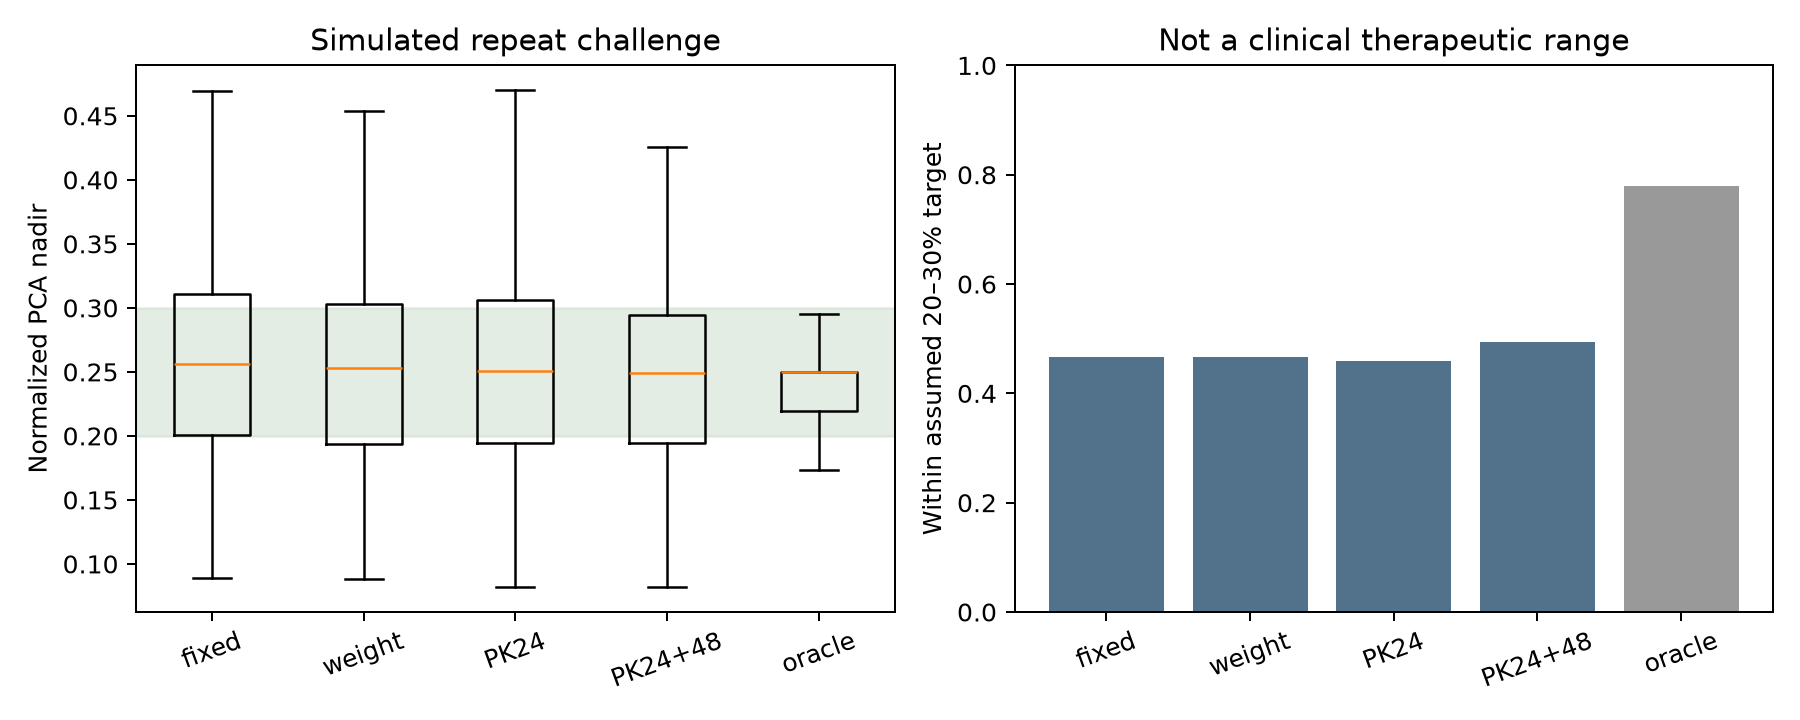

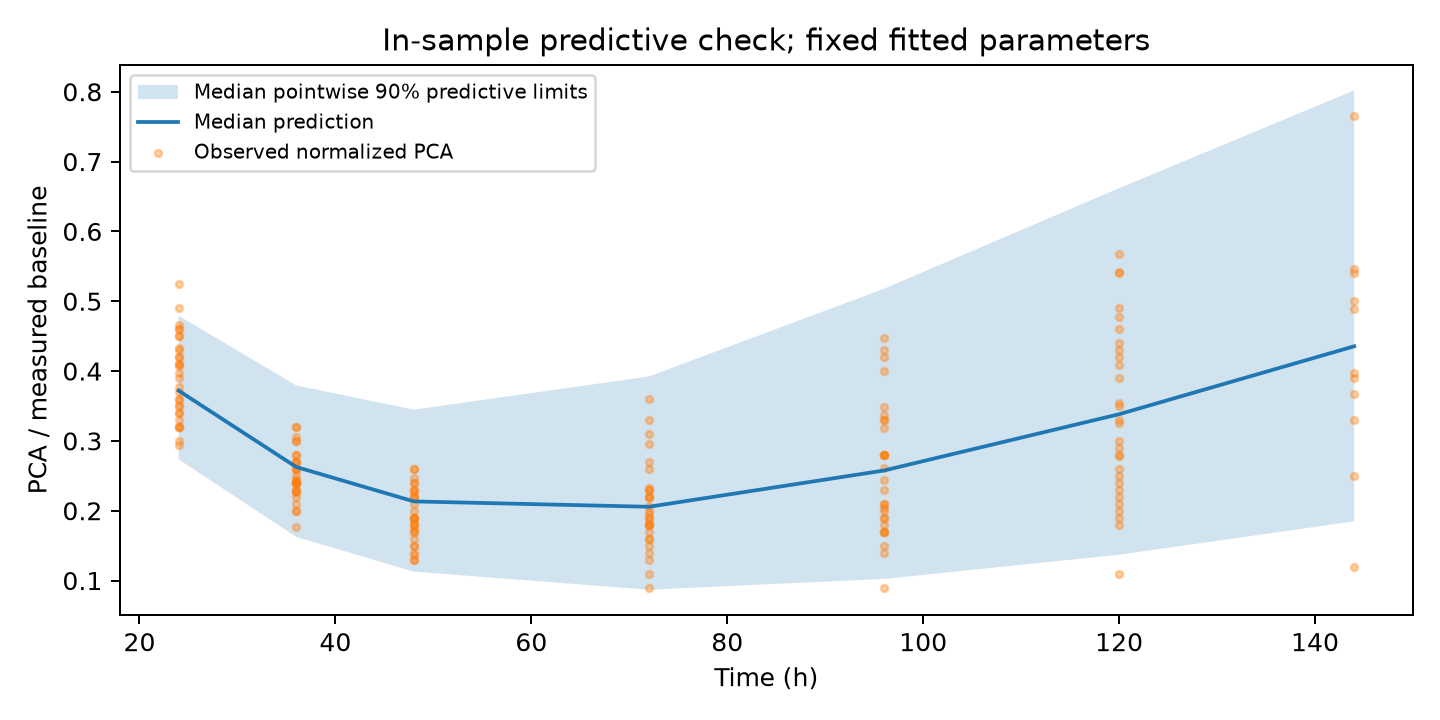

In [4]:
for p in sorted(Path('figures').glob('*.png')):
    display(Image(filename=str(p)))

## Interpretation
No consistent improvement in held-out PCA prediction from limited PK was established. Optimizer warnings and conditional sequential fitting preclude strong model qualification or formal parameter confidence intervals. Simulation is exploratory and unvalidated. No publication date was assigned.